# Diabetes Risk Prediction Using Explainable AI

## Project Overview

Diabetes is a major public health issue. Early identification of people who may be at risk can help healthcare providers and public health organisations plan better prevention strategies.

This project uses health, lifestyle, and demographic indicators to predict whether a person is at risk of diabetes. The project also applies Explainable AI methods, such as SHAP and LIME, to understand which factors influence the model's predictions.

The goal is not only to build a machine learning model, but also to explain the model’s decisions in a way that can be understood by non-technical stakeholders.

In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# XAI libraries
import shap
from lime.lime_tabular import LimeTabularExplainer

# Display settings
pd.set_option("display.max_columns", None)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load the dataset
df = pd.read_csv("C:\\Users\\MAGWALI\\diabetes-risk-xai\\data\\diabetes_012_health_indicators_BRFSS2015.csv")

# Display the first five rows
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [4]:
# Check the number of rows and columns
df.shape

(253680, 22)

In [5]:
# Check column names
df.columns

Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

## Dataset Description

The dataset used in this project is the Diabetes Health Indicators dataset from the Behavioral Risk Factor Surveillance System.

The dataset contains health, lifestyle, and demographic variables. These include blood pressure, cholesterol, BMI, smoking status, physical activity, general health, age, education, and income.

The original target variable is `Diabetes_012`, where:

- 0 = No diabetes
- 1 = Prediabetes
- 2 = Diabetes

Since the prediabetes class is much smaller than the other classes, this project converts the task into a binary classification problem:

- 0 = No diabetes
- 1 = Prediabetes or diabetes risk

In [6]:
# Create a binary target variable
# 0 = No diabetes
# 1 = Prediabetes or diabetes

df["Diabetes_binary"] = df["Diabetes_012"].replace({
    0: 0,
    1: 1,
    2: 1
})

# Check the new target distribution
df["Diabetes_binary"].value_counts()

Diabetes_binary
0.0    213703
1.0     39977
Name: count, dtype: int64

In [7]:
# Check target distribution as percentages
df["Diabetes_binary"].value_counts(normalize=True) * 100

Diabetes_binary
0.0    84.24117
1.0    15.75883
Name: proportion, dtype: float64

## Target Variable Transformation

The original target variable had three classes: no diabetes, prediabetes, and diabetes. However, the prediabetes group is much smaller than the other groups, which can make multiclass classification difficult.

To make the problem more practical and easier to interpret, the target was converted into a binary classification problem. Individuals with prediabetes or diabetes were grouped together as the "at risk" group.

This allows the model to answer a clear healthcare question:

**Can we identify individuals who may be at risk of diabetes based on their health indicators?**

In [8]:
# Set visual style
sns.set_theme(style="whitegrid")

# Custom project colour palette
blue = "#1f77b4"
orange = "#ff7f0e"
yellow = "#f2c94c"

project_palette = [blue, orange, yellow]

# Palette for diabetes risk classes
risk_palette = {
    0: blue,
    1: orange
}

## Exploratory Data Analysis

This section explores the main patterns in the dataset before modelling. The goal is to understand how diabetes risk is related to health, lifestyle, and demographic indicators such as BMI, blood pressure, cholesterol, physical activity, general health, age, education, and income.



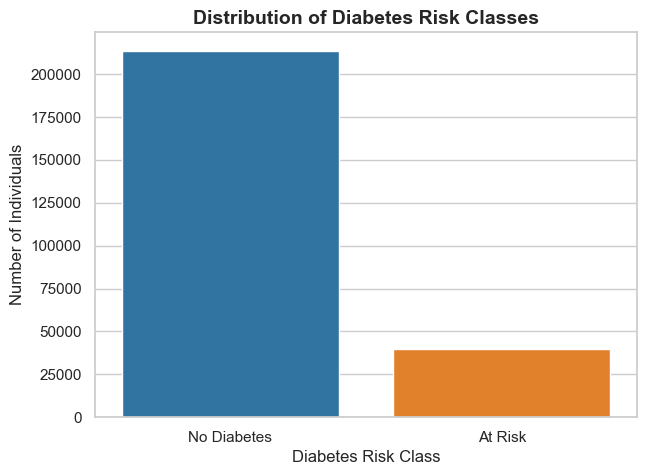

In [19]:
# Make sure the target column is stored as integers
df["Diabetes_binary"] = df["Diabetes_binary"].astype(int)
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Diabetes_binary",
    palette={"0": blue, "1": orange}
)

plt.title("Distribution of Diabetes Risk Classes", fontsize=14, fontweight="bold")
plt.xlabel("Diabetes Risk Class")
plt.ylabel("Number of Individuals")
plt.xticks([0, 1], ["No Diabetes", "At Risk"])

plt.show()



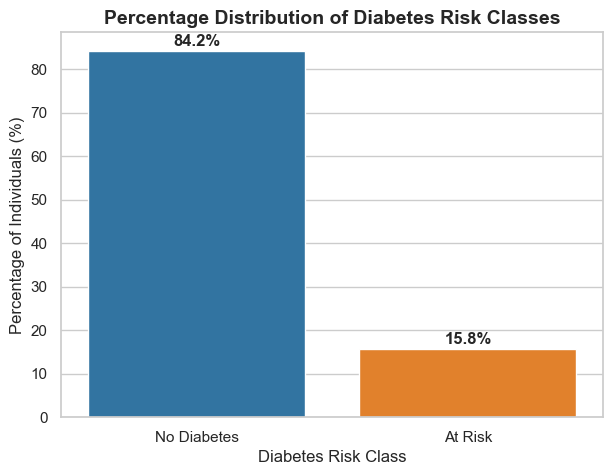

In [27]:
target_percentages = (
    df["Diabetes_binary"]
    .value_counts(normalize=True)
    .reset_index()
)

target_percentages.columns = ["Diabetes_binary", "Percentage"]
target_percentages["Percentage"] = target_percentages["Percentage"] * 100

plt.figure(figsize=(7, 5))

sns.barplot(
    data=target_percentages,
    x="Diabetes_binary",
    y="Percentage",
    palette=[blue, orange]
)

plt.title("Percentage Distribution of Diabetes Risk Classes", fontsize=14, fontweight="bold")
plt.xlabel("Diabetes Risk Class")
plt.ylabel("Percentage of Individuals (%)")
plt.xticks([0, 1], ["No Diabetes", "At Risk"])

for index, row in target_percentages.iterrows():
    plt.text(
        index,
        row["Percentage"] + 1,
        f"{row['Percentage']:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.show()


The percentage distribution confirms that the diabetes-risk group is much smaller than the no-diabetes group. This class imbalance needs to be considered when training and evaluating the machine learning models.

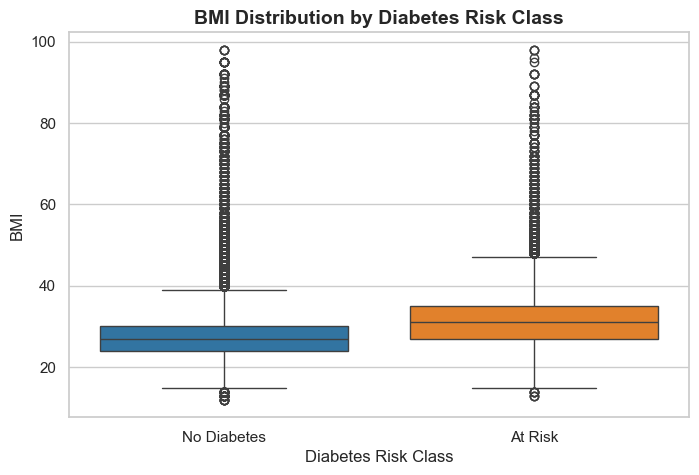

In [33]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Diabetes_binary",
    y="BMI",
    order=[0, 1],
    palette=[blue, orange]
)

plt.title("BMI Distribution by Diabetes Risk Class", fontsize=14, fontweight="bold")
plt.xlabel("Diabetes Risk Class")
plt.ylabel("BMI")
plt.xticks([0, 1], ["No Diabetes", "At Risk"])

plt.show()


This boxplot compares BMI values for individuals with no diabetes and individuals at risk of diabetes. If the at-risk group has a higher median BMI, this suggests that BMI may be an important factor for predicting diabetes risk.

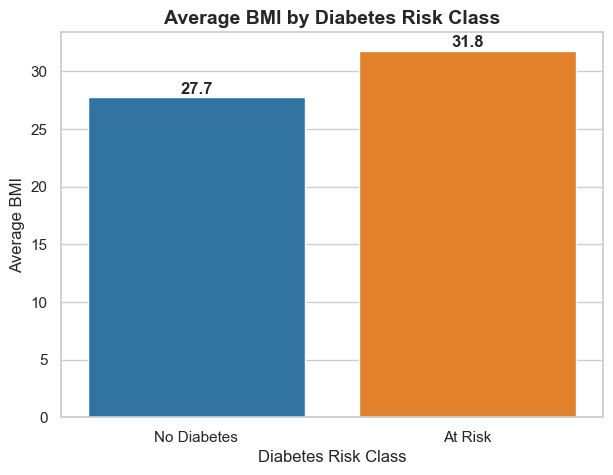

In [35]:
bmi_summary = (
    df.groupby("Diabetes_binary")["BMI"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7, 5))


sns.barplot(
    data=bmi_summary,
    x="Diabetes_binary",
    y="BMI",
    palette=[blue, orange]
)

plt.title("Average BMI by Diabetes Risk Class", fontsize=14, fontweight="bold")
plt.xlabel("Diabetes Risk Class")
plt.ylabel("Average BMI")
plt.xticks([0, 1], ["No Diabetes", "At Risk"])

for index, row in bmi_summary.iterrows():
    plt.text(
        index,
        row["BMI"] + 0.3,
        f"{row['BMI']:.1f}",
        ha="center",
        fontweight="bold"
    )

plt.show()



The average BMI graph helps compare the typical BMI level between the two groups. A higher average BMI in the at-risk group would support the idea that BMI is strongly linked to diabetes risk.

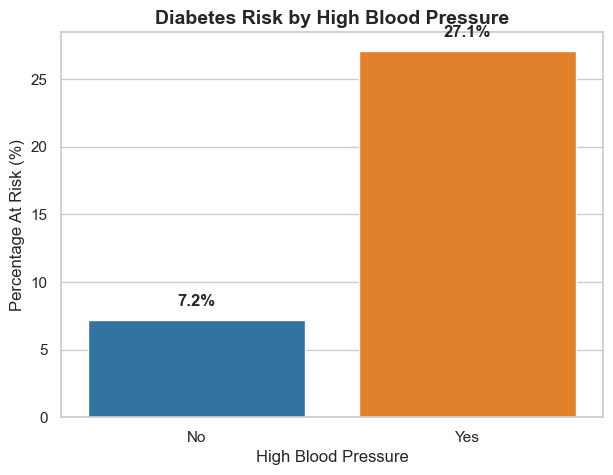

In [36]:
highbp_risk = (
    df.groupby("HighBP")["Diabetes_binary"]
    .mean()
    .reset_index()
)

highbp_risk["Risk_Percentage"] = highbp_risk["Diabetes_binary"] * 100

plt.figure(figsize=(7, 5))

sns.barplot(
    data=highbp_risk,
    x="HighBP",
    y="Risk_Percentage",
    palette=[blue, orange]
)

plt.title("Diabetes Risk by High Blood Pressure", fontsize=14, fontweight="bold")
plt.xlabel("High Blood Pressure")
plt.ylabel("Percentage At Risk (%)")
plt.xticks([0, 1], ["No", "Yes"])

for index, row in highbp_risk.iterrows():
    plt.text(
        index,
        row["Risk_Percentage"] + 1,
        f"{row['Risk_Percentage']:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.show()

This graph shows the percentage of individuals at risk of diabetes among those with and without high blood pressure. If the percentage is higher for individuals with high blood pressure, this suggests that blood pressure is an important risk indicator.

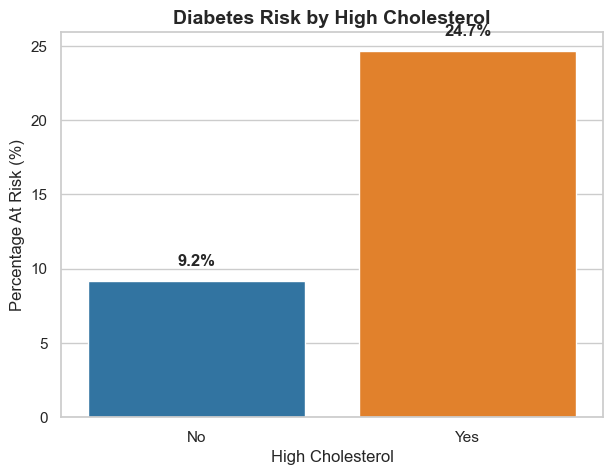

In [37]:
highchol_risk = (
    df.groupby("HighChol")["Diabetes_binary"]
    .mean()
    .reset_index()
)

highchol_risk["Risk_Percentage"] = highchol_risk["Diabetes_binary"] * 100

plt.figure(figsize=(7, 5))

sns.barplot(
    data=highchol_risk,
    x="HighChol",
    y="Risk_Percentage",
    palette=[blue, orange]
)

plt.title("Diabetes Risk by High Cholesterol", fontsize=14, fontweight="bold")
plt.xlabel("High Cholesterol")
plt.ylabel("Percentage At Risk (%)")
plt.xticks([0, 1], ["No", "Yes"])

for index, row in highchol_risk.iterrows():
    plt.text(
        index,
        row["Risk_Percentage"] + 1,
        f"{row['Risk_Percentage']:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.show()

This graph compares diabetes risk between individuals with and without high cholesterol. A higher percentage of at-risk individuals among those with high cholesterol would suggest that cholesterol level is an important health indicator for the model.

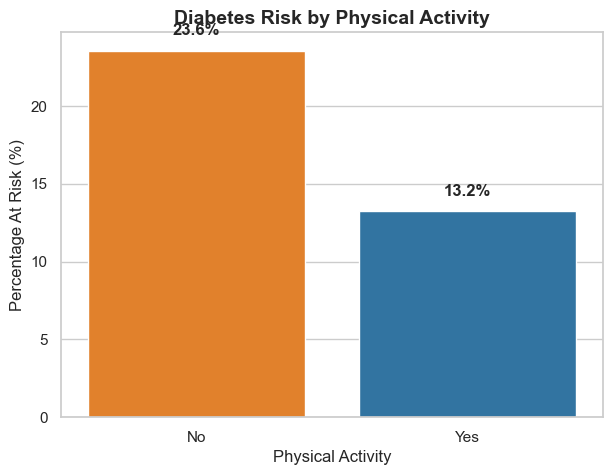

In [38]:
activity_risk = (
    df.groupby("PhysActivity")["Diabetes_binary"]
    .mean()
    .reset_index()
)

activity_risk["Risk_Percentage"] = activity_risk["Diabetes_binary"] * 100

plt.figure(figsize=(7, 5))

sns.barplot(
    data=activity_risk,
    x="PhysActivity",
    y="Risk_Percentage",
    palette=[orange, blue]
)

plt.title("Diabetes Risk by Physical Activity", fontsize=14, fontweight="bold")
plt.xlabel("Physical Activity")
plt.ylabel("Percentage At Risk (%)")
plt.xticks([0, 1], ["No", "Yes"])

for index, row in activity_risk.iterrows():
    plt.text(
        index,
        row["Risk_Percentage"] + 1,
        f"{row['Risk_Percentage']:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.show()

This graph shows how diabetes risk differs between individuals who reported physical activity and those who did not. If the risk percentage is lower among physically active individuals, this may suggest that physical activity is associated with lower diabetes risk.

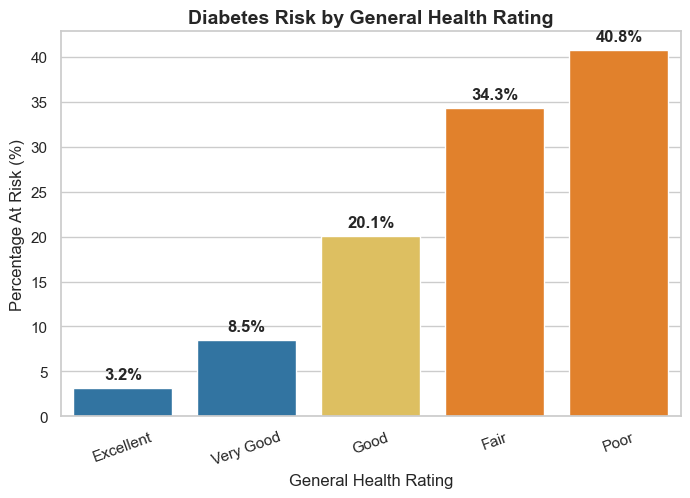

In [39]:
genhlth_risk = (
    df.groupby("GenHlth")["Diabetes_binary"]
    .mean()
    .reset_index()
)

genhlth_risk["Risk_Percentage"] = genhlth_risk["Diabetes_binary"] * 100

plt.figure(figsize=(8, 5))

sns.barplot(
    data=genhlth_risk,
    x="GenHlth",
    y="Risk_Percentage",
    palette=[blue, blue, yellow, orange, orange]
)

plt.title("Diabetes Risk by General Health Rating", fontsize=14, fontweight="bold")
plt.xlabel("General Health Rating")
plt.ylabel("Percentage At Risk (%)")
plt.xticks(
    [0, 1, 2, 3, 4],
    ["Excellent", "Very Good", "Good", "Fair", "Poor"],
    rotation=20
)

for index, row in genhlth_risk.iterrows():
    plt.text(
        index,
        row["Risk_Percentage"] + 1,
        f"{row['Risk_Percentage']:.1f}%",
        ha="center",
        fontweight="bold"
    )

plt.show()

General health is an ordinal variable, where lower values represent better health and higher values represent poorer health. This graph shows whether diabetes risk increases as self-reported general health becomes worse.

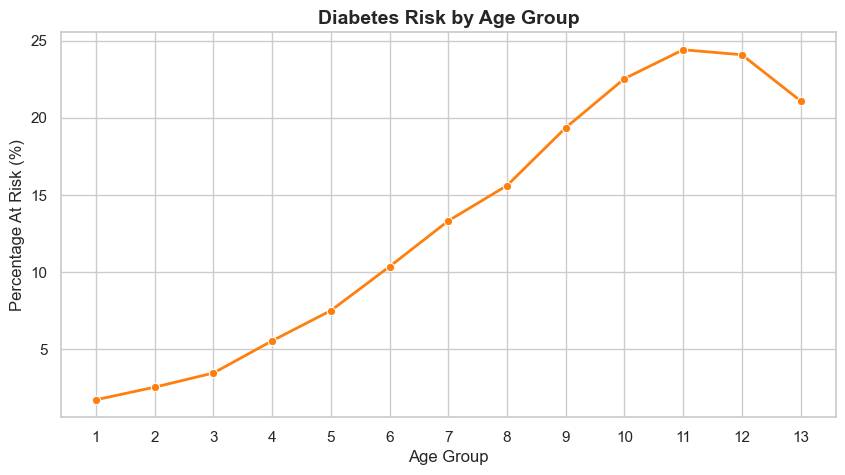

In [40]:
age_risk = (
    df.groupby("Age")["Diabetes_binary"]
    .mean()
    .reset_index()
)

age_risk["Risk_Percentage"] = age_risk["Diabetes_binary"] * 100

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=age_risk,
    x="Age",
    y="Risk_Percentage",
    marker="o",
    color=orange,
    linewidth=2
)

plt.title("Diabetes Risk by Age Group", fontsize=14, fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("Percentage At Risk (%)")
plt.xticks(age_risk["Age"])

plt.show()

This line graph shows how diabetes risk changes across age groups. If the line rises as age increases, this suggests that older individuals are more likely to be in the diabetes-risk group.

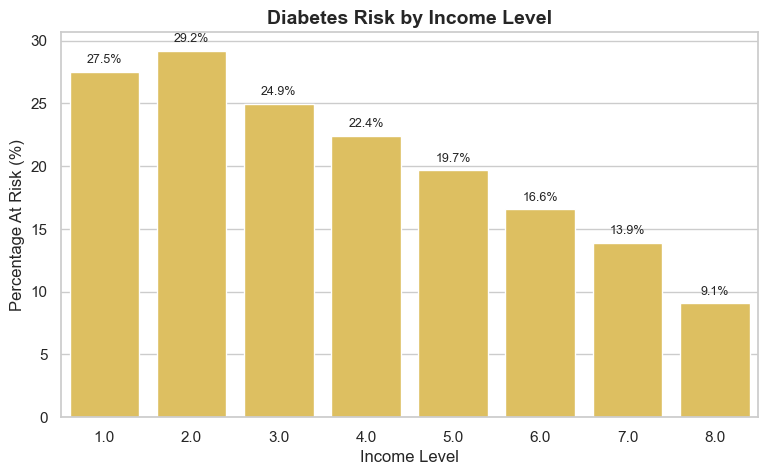

In [41]:
income_risk = (
    df.groupby("Income")["Diabetes_binary"]
    .mean()
    .reset_index()
)

income_risk["Risk_Percentage"] = income_risk["Diabetes_binary"] * 100

plt.figure(figsize=(9, 5))

sns.barplot(
    data=income_risk,
    x="Income",
    y="Risk_Percentage",
    color=yellow
)

plt.title("Diabetes Risk by Income Level", fontsize=14, fontweight="bold")
plt.xlabel("Income Level")
plt.ylabel("Percentage At Risk (%)")

for index, row in income_risk.iterrows():
    plt.text(
        index,
        row["Risk_Percentage"] + 0.7,
        f"{row['Risk_Percentage']:.1f}%",
        ha="center",
        fontsize=9
    )

plt.show()

This graph explores how diabetes risk differs across income levels. If lower income groups have higher diabetes risk, this may suggest that socioeconomic factors are related to health outcomes.

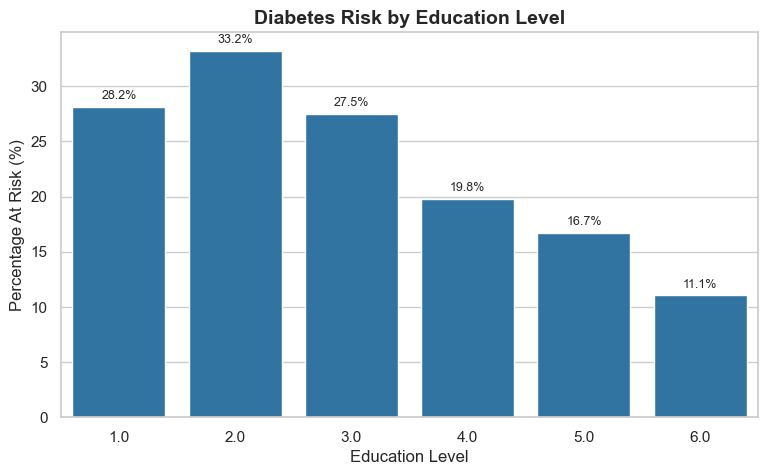

In [42]:
education_risk = (
    df.groupby("Education")["Diabetes_binary"]
    .mean()
    .reset_index()
)

education_risk["Risk_Percentage"] = education_risk["Diabetes_binary"] * 100

plt.figure(figsize=(9, 5))

sns.barplot(
    data=education_risk,
    x="Education",
    y="Risk_Percentage",
    color=blue
)

plt.title("Diabetes Risk by Education Level", fontsize=14, fontweight="bold")
plt.xlabel("Education Level")
plt.ylabel("Percentage At Risk (%)")

for index, row in education_risk.iterrows():
    plt.text(
        index,
        row["Risk_Percentage"] + 0.7,
        f"{row['Risk_Percentage']:.1f}%",
        ha="center",
        fontsize=9
    )

plt.show()

This graph examines whether diabetes risk differs by education level. Differences across education groups may help explain how social and demographic factors relate to diabetes risk.

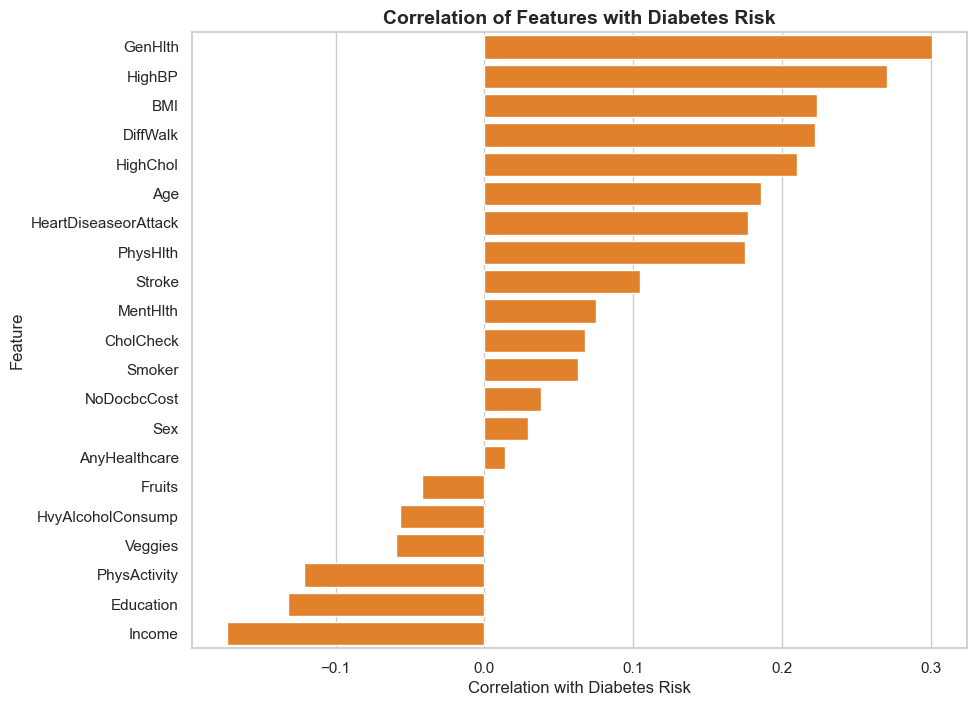

In [43]:
correlations = (
    df.drop(columns=["Diabetes_012"])
    .corr()["Diabetes_binary"]
    .sort_values(ascending=False)
    .reset_index()
)

correlations.columns = ["Feature", "Correlation"]
correlations = correlations[correlations["Feature"] != "Diabetes_binary"]

plt.figure(figsize=(10, 8))

sns.barplot(
    data=correlations,
    x="Correlation",
    y="Feature",
    color=orange
)

plt.title("Correlation of Features with Diabetes Risk", fontsize=14, fontweight="bold")
plt.xlabel("Correlation with Diabetes Risk")
plt.ylabel("Feature")

plt.show()

This graph shows which features have the strongest positive or negative correlation with diabetes risk. Positive correlations suggest that higher values of the feature are associated with higher diabetes risk, while negative correlations suggest that higher values may be associated with lower diabetes risk.

## Summary of EDA Findings

The exploratory data analysis showed that the diabetes-risk group is smaller than the no-diabetes group, meaning that the dataset is imbalanced. This will be important during model evaluation because accuracy alone may give a misleading impression of model performance.

Several health indicators appear to be related to diabetes risk. Individuals in the at-risk group tend to have higher BMI values. Diabetes risk also appears higher among individuals with high blood pressure and high cholesterol. General health shows a clear pattern, where individuals reporting poorer health tend to have a higher percentage of diabetes risk.

The analysis also suggests that demographic and lifestyle factors may play a role. Diabetes risk appears to change across age groups, income levels, education levels, and physical activity status. These patterns support the use of Explainable AI methods later in the project, because stakeholders need to understand which factors influence the model’s predictions.